In [ ]:
# 加载图像
from torch.utils.data import Dataset
from torchvision import transforms
import torch
import os
from pathlib import Path
import numpy as np
from PIL import Image
from diffusers import AutoencoderKL, DDPMScheduler, DiffusionPipeline, UNet2DConditionModel
from transformers.models.clip.modeling_clip import CLIPVisionModelWithProjection


resample_interpolation = transforms.InterpolationMode.BILINEAR
center_crop = True
target_image_path="/data1/humw/Datasets/VGGFace2/n000050/set_B/0012_01.png"
resolution = 512
eot = 0
torch_dtype = torch.bfloat16
pretrained_model_name_or_path="/data1/humw/Pretrains/stable-diffusion-v1-5"
revision="bf16"

vae = AutoencoderKL.from_pretrained(
        pretrained_model_name_or_path, subfolder="vae", revision=revision).cuda().to(dtype=torch_dtype)

vae.requires_grad_(False)

ipadapter_path = "/data1/humw/Pretrains/IP-Adapter/models/image_encoder"
ipadapter = CLIPVisionModelWithProjection.from_pretrained(ipadapter_path).cuda().to(dtype=torch_dtype).requires_grad_(False)
        
if eot == 0: # 不用eot，不过ipadapter因为尺寸不一致不得不用eot
    trans_224 = [
        transforms.Resize(224, interpolation=resample_interpolation),
        transforms.CenterCrop(224) if center_crop else transforms.RandomCrop(224),
    ]
    trans_224 = transforms.Compose(trans_224)
else: # 使用eot
    resample_interpolation = transforms.InterpolationMode.BILINEAR
        
    train_aug_224 = [
        transforms.Resize(224, interpolation=resample_interpolation),
        transforms.CenterCrop(224) if center_crop else transforms.RandomCrop(224),
    ]
    tensorize_and_normalize = [
        transforms.Normalize([0.5*255]*3,[0.5*255]*3),
    ]
    trans_224 = train_aug_224 + tensorize_and_normalize
    trans_224 = transforms.Compose(trans_224)
    print("all_trans:{}".format(trans_224))
    
    train_aug_512 = [
        transforms.Resize(512, interpolation=resample_interpolation),
        transforms.CenterCrop(512) if center_crop else transforms.RandomCrop(512),
    ]
    trans_512 = train_aug_512 + tensorize_and_normalize
    trans_512 = transforms.Compose(trans_512)
    print("all_trans:{}".format(trans_512))
    pgd_eps = 16.0
    pgd_alpha = 16/10 # 默认是阈值的1/10


target_image_path = Path(target_image_path)
assert target_image_path.is_file(), f"Target image path {target_image_path} does not exist"

target_image = Image.open(target_image_path).convert("RGB").resize((resolution, resolution))
target_image = np.array(target_image)[None].transpose(0, 3, 1, 2)
if eot == 0:
    target_image_tensor = torch.from_numpy(target_image).to("cuda", dtype=torch_dtype) / 127.5 - 1.0
    target_latent_tensor = (
        vae.encode(target_image_tensor).latent_dist.sample().to(dtype=torch_dtype) * vae.config.scaling_factor
    )
else:
    # import pdb; pdb.set_trace()
    target_image_tensor = torch.from_numpy(target_image).to("cuda", dtype=torch_dtype)
    target_latent_tensor = (
        vae.encode(trans_512(target_image_tensor)).latent_dist.sample().to(dtype=torch_dtype) * vae.config.scaling_factor
    )

# get ipadapter target latent tensor
ipadapter_target_tensor  = ipadapter(trans_224(target_image_tensor), output_hidden_states=True).hidden_states[-2].detach()

In [ ]:
# 将不同特征放缩到相同尺度，然后计算余弦相似度 NKO 这条路行不通，因为特征的尺度相差太大
print(target_latent_tensor.shape)
print(ipadapter_target_tensor.shape)

In [ ]:
# 获取不同模型上对抗样本的梯度，然后计算余弦相似度
## 思路：直接获取第一轮各个模型上的图像梯度（预先损失），然后计算模型梯度之间的余弦相似度
# 完整SD模型：SD14、SD15、SD21、SDXL、SD3
# 图像编码器：ipadapter_clip, photomaker_clip, clip-vit-large-patch14, SD14_VAE, SD15_VAE, SD21_VAE, SDXL_VAE
# 两张对比图：一张是agm前的梯度热力图，一张是agm后的梯度热力图

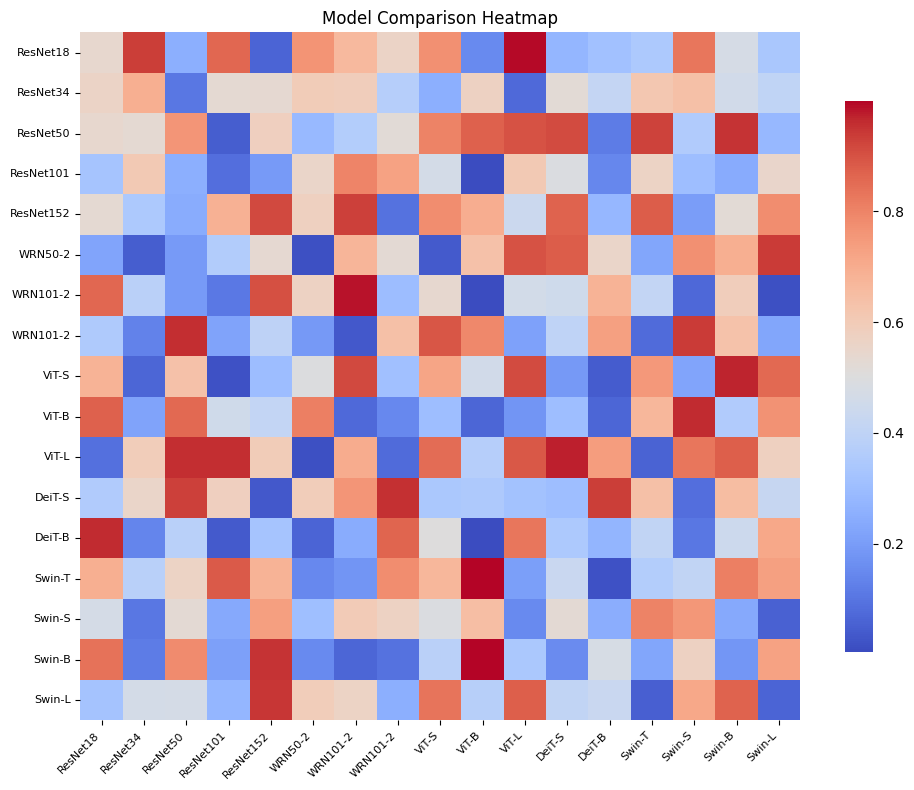

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models = ["ResNet18", "ResNet34", "ResNet50", "ResNet101", "ResNet152",
          "WRN50-2", "WRN101-2", "WRN101-2", "ViT-S", "ViT-B", "ViT-L",
          "DeiT-S", "DeiT-B", "Swin-T", "Swin-S", "Swin-B", "Swin-L"]
data = np.random.rand(len(models), len(models))  # 随机生成数据

# 创建热图
plt.figure(figsize=(10, 8))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models, yticklabels=models, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# non target 第一轮：
# alpha:  tensor([9.9994e-01, 1.0799e-05, 4.4424e-05], device='cuda:0')
# losses_dict: {'unet': tensor(-0.9688, device='cuda:0', dtype=torch.bfloat16, grad_fn=<NegBackward0>), 'vae': tensor(-0.8633, device='cuda:0', dtype=torch.bfloat16, grad_fn=<NegBackward0>), 'ipadapter': tensor(-0.7812, device='cuda:0', dtype=torch.bfloat16, grad_fn=<NegBackward0>)}
# before agm: 
# cos_sim_matrix: 
#  [[ 8.57990444e-01  9.30835307e-02  1.19683042e-04]
#  [ 9.30835307e-02  1.00000000e+00 -4.69329389e-04]
#  [ 1.19683042e-04 -4.69329389e-04  8.75000000e-01]]
 # after agm: 
# alphas_cos_sim_matrix: 
#  [[ 8.57990444e-01  9.02740983e-04 -3.00288462e-04]
#  [ 9.02740983e-04  5.05675853e-05 -9.07873016e-07]
#  [-3.00288462e-04 -9.07873016e-07  2.71712523e-02]]


# before agm: 
# cos_sim_matrix: 

# 余弦相似度似乎有问题，自己和自己都得不到1: 就是数值太小了，误差就会很大
# agm代码有问题，alphas之和不是1： 没有问题，和是1

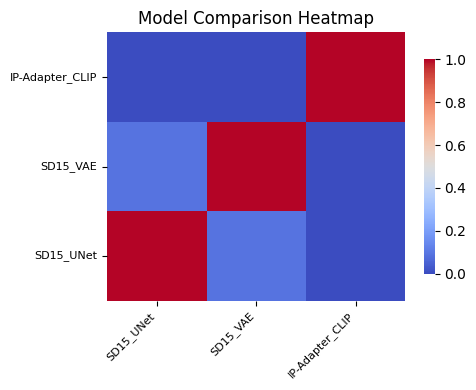

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data = [[1.19683042e-04, -4.69329389e-04, 1], 
        [9.30835307e-02, 1, -4.69329389e-04], 
        [1, 9.30835307e-02, 1.19683042e-04],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

# after agm: 
# alphas_cos_sim_matrix: 

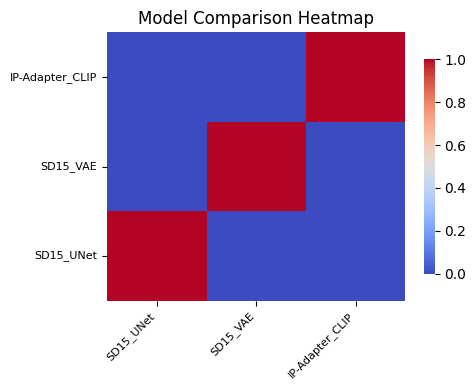

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data =  [[-3.00288462e-04, -9.07873016e-07, 1],
         [ 9.02740983e-04,  1, -9.07873016e-07],
         [1 ,9.02740983e-04 ,-3.00288462e-04],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# mist 第一轮：
# alpha:  tensor([7.5176e-01, 2.4824e-01, 4.0629e-07], device='cuda:0')
# losses_dict: {'unet': tensor(-0.0052, device='cuda:0', dtype=torch.bfloat16, grad_fn=<MeanBackward0>), 'vae': tensor(0.0537, device='cuda:0', dtype=torch.bfloat16, grad_fn=<MeanBackward0>), 'ipadapter': tensor(0.1235, device='cuda:0', dtype=torch.bfloat16, grad_fn=<MeanBackward0>)}
# cos_sim_matrix: 
#  [[ 1.00000000e+00  8.16762447e-01 -3.80436395e-04]
#  [ 8.16762447e-01  1.00000000e+00  1.52671870e-04]
#  [-3.80436395e-04  1.52671870e-04  8.75000000e-01]]
# alphas_cos_sim_matrix: 
#  [[ 1.00000000e+00  8.16762388e-01 -1.66707321e-06]
#  [ 8.16762388e-01  1.00000000e+00 -5.44794091e-07]
#  [-1.66707321e-06 -5.44794091e-07  4.76952948e-07]]
# alpha:  tensor([7.5831e-01, 2.4169e-01, 4.1717e-07], device='cuda:0')
# cos_sim_matrix: 
#  [[ 1.00000000e+00  8.16592634e-01 -3.77623364e-04]
#  [ 8.16592634e-01  1.00000000e+00  1.52671870e-04]
#  [-3.77623364e-04  1.52671870e-04  8.75000000e-01]]
# alphas_cos_sim_matrix: 
#  [[ 1.00000000e+00  8.16592634e-01 -1.75621926e-06]
#  [ 8.16592634e-01  1.00000000e+00 -5.73196360e-07]
#  [-1.75621926e-06 -5.73196360e-07  5.27980376e-07]]

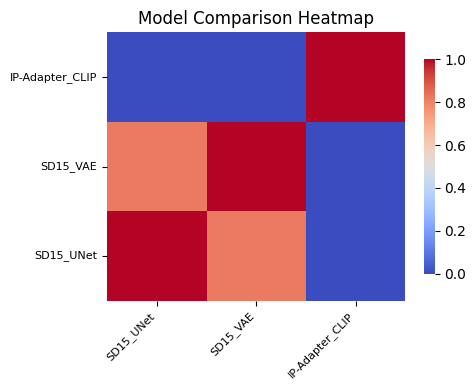

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data =  [[-3.80436395e-04,  1.52671870e-04,  1],
         [ 8.16762447e-01,  1.00000000e+00 , 1.52671870e-04],
         [ 1.00000000e+00,  8.16762447e-01, -3.80436395e-04],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

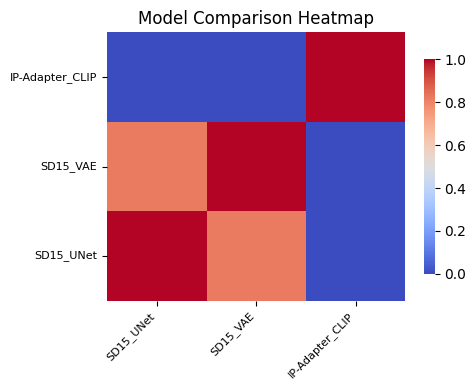

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data =  [[-1.66707321e-06, -5.44794091e-07,  1],
         [ 8.16762447e-01,  1.00000000e+00, 1.52671870e-04],
         [ 1.00000000e+00, 8.16762388e-01, -1.66707321e-06],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import torch.nn.functional as F
import torch

grad_list = [torch.tensor(1.0), torch.tensor(-2.0), torch.tensor(3.0)]
# 定义一个3*3 numpy矩阵，矩阵的每个元素是grd_list[i]和grad_list[j]的余弦相似度分数
cos_sim_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        cos_sim_matrix[i][j] = F.cosine_similarity(grad_list[i], grad_list[j], -1).mean()
print("cos_sim_matrix: \n", cos_sim_matrix)

cos_sim_matrix: 
 [[ 1. -1.  1.]
 [-1.  1. -1.]
 [ 1. -1.  1.]]


In [7]:
import torch
import torch.nn.functional as F

# 定义两个向量
vector1 = torch.tensor([1.0, 2.0, 3.0])
vector2 = torch.tensor([4.0, 5.0, 6.0])

# 计算余弦相似度
similarity = F.cosine_similarity(vector1.unsqueeze(0), vector2.unsqueeze(0))
print(similarity)  # 输出: tensor([0.9746])}

tensor([0.9746])


In [8]:
vector1.unsqueeze(0)

tensor([[1., 2., 3.]])

In [14]:
import torch
import torch.nn.functional as F

# 定义一个批次的向量
batch_vectors1 = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0]
])

batch_vectors2 = torch.tensor([
    [2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0],
    [8.0, 9.0, 10.0]
])

# 计算每对向量的余弦相似度
similarities = F.cosine_similarity(batch_vectors1, batch_vectors2, dim=1)
print(similarities)  
# 输出: tensor([0.9926, 0.9984, 0.9996])

tensor([0.9926, 0.9996, 0.9999])


In [15]:
mean_similarities = F.cosine_similarity(batch_vectors1, batch_vectors2, dim=1).mean()
print(mean_similarities)  

tensor(0.9974)


In [ ]:
mean_similarities = F.cosine_similarity(batch_vectors1, batch_vectors2, dim=-1).mean()
print(mean_similarities)  

tensor(1.)


# 不同模型上生成扰动的相似度

In [26]:
# 检测图像阈值，MetaCloak模式
from torchvision import transforms
import torch
from pathlib import Path
from PIL import Image

def load_data(data_dir, size=512, center_crop=True) -> torch.Tensor:
    image_transforms = transforms.Compose(
        [
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
            transforms.ToTensor(),
            # transforms.Normalize([0.5], [0.5]),
        ]
    )

    images = [image_transforms(Image.open(i).convert("RGB")) for i in sorted(list(Path(data_dir).iterdir()))]
    images = torch.stack(images)
    return images

weight_type = torch.bfloat16
clean_images = load_data('/data1/humw/Datasets/VGGFace2/n000050/set_B').to(dtype=weight_type)
adv_images_of_unet = load_data('/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/ASPL_ace-plus-ipadapter_VGGFace2_SD15_unet_mist_agm_cosine_eot-1/n000050').to(dtype=weight_type)
adv_images_of_vae = load_data('/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae_mist_agm_cosine_eot-1/n000050').to(dtype=weight_type)
adv_images_of_clip = load_data('/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/ASPL_ace-plus-ipadapter_VGGFace2_SD15_ipadapter_mist_agm_cosine_eot-1/n000050').to(dtype=weight_type)

et_of_unet = adv_images_of_unet - clean_images
et_of_vae = adv_images_of_vae - clean_images
et_of_clip = adv_images_of_clip - clean_images

In [36]:
print(et_of_clip.shape)
print(et_of_clip.mean())
print(et_of_clip.std())
print(et_of_clip.min())
print(et_of_clip.max())
print(F.cosine_similarity(sum(et_of_clip), sum(et_of_clip), -1).mean())

torch.Size([4, 3, 512, 512])
tensor(0.0001, dtype=torch.bfloat16)
tensor(0.0386, dtype=torch.bfloat16)
tensor(-0.0645, dtype=torch.bfloat16)
tensor(0.0645, dtype=torch.bfloat16)
tensor(0.8750, dtype=torch.bfloat16)


In [28]:
import numpy as np
import torch.nn.functional as F

et_list = [et_of_unet, et_of_vae, et_of_clip]
# 定义一个3*3 numpy矩阵，矩阵的每个元素是grd_list[i]和grad_list[j]的余弦相似度分数
cos_sim_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        cos_sim_matrix[i][j] = F.cosine_similarity(et_list[i], et_list[j], -1).mean()
print("cos_sim_matrix: \n", cos_sim_matrix)

cos_sim_matrix: 
 [[1.         0.29296875 0.02307129]
 [0.29296875 1.         0.03320312]
 [0.02307129 0.03320312 0.875     ]]


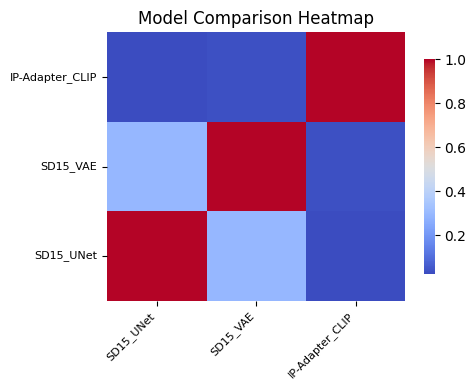

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data =  [[0.02307129, 0.03320312, 1],
         [0.29296875, 1., 0.03320312],
         [1. , 0.29296875, 0.02307129],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

<!DOCTYPE html>
<html lang="zh-CN">
<head>
    <meta charset="UTF-8">
    <title>六一的零花钱小管家计划</title>
    <style>
        :root {
            --red: #ff9999;
            --blue: #99ccff;
            --yellow: #fff099;
        }

        body {
            font-family: "Comic Sans MS", 楷体, cursive;
            max-width: 800px;
            margin: 20px auto;
            padding: 20px;
            background: #f0f9ff;
        }

        .contract {
            border: 3px solid #99ccff;
            border-radius: 15px;
            padding: 25px;
            background: white;
            box-shadow: 0 0 15px rgba(0,0,0,0.1);
        }

        h1 {
            color: #ff6b6b;
            text-align: center;
            font-size: 2.5em;
            margin-bottom: 30px;
            text-shadow: 2px 2px 2px rgba(0,0,0,0.1);
        }

        .section {
            margin: 25px 0;
            padding: 15px;
            border-radius: 10px;
        }

        .rights { background: var(--red); }
        .wallets { background: var(--blue); }
        .promise { background: var(--yellow); }
        .rules { border: 2px dashed #99ccff; }

        .icon {
            font-size: 1.5em;
            margin-right: 10px;
        }

        .signature-box {
            margin-top: 40px;
            text-align: center;
        }

        .signature {
            display: inline-block;
            width: 250px;
            border-bottom: 2px solid black;
            margin: 20px;
        }

        @media print {
            body { background: white; }
            .contract { box-shadow: none; }
            .section { break-inside: avoid; }
        }
    </style>
</head>
<body>
    <div class="contract">
        <h1>✨ 六一的零花钱小管家计划 ✨</h1>
        
        <div class="section rights">
            <h2>📜 六一的权利</h2>
            <p>✅ 每月1号收到50元零花钱</p >
            <p>✅ 可以自己决定买：</p >
            <ul>
                <li>🍭 小零食（棒棒糖、酸奶）</li>
                <li>🚗 小玩具（不超过30元）</li>
                <li>🎁 送朋友的小礼物</li>
            </ul>
        </div>

        <div class="section wallets">
            <h2>🎒 三个魔法钱包</h2>
            <div style="display: flex; gap: 20px; margin-top: 15px;">
                <div style="flex:1; background:var(--red); padding:10px; border-radius:8px;">
                    <h3>🔴 红色钱包 (30元)</h3>
                    <p>每周最多买3次零食</p >
                </div>
                <div style="flex:1; background:var(--blue); padding:10px; border-radius:8px;">
                    <h3>🔵 蓝色存钱罐 (15元)</h3>
                    <p>存满3个月打开</p >
                </div>
                <div style="flex:1; background:var(--yellow); padding:10px; border-radius:8px;">
                    <h3>🟡 黄色爱心盒 (5元)</h3>
                    <p>帮助其他小朋友</p >
                </div>
            </div>
        </div>

        <div class="section promise">
            <h2>🤝 爸爸的承诺</h2>
            <ul>
                <li>⏰ 每月按时发零花钱</li>
                <li>🛒 教你看价格标签</li>
                <li>📒 准备漂亮记账本</li>
            </ul>
        </div>

        <div class="section rules">
            <h2>❗ 重要约定</h2>
            <p>⚖ 钱用完要等到下个月</p >
            <p>📆 每周六一起数钱</p >
            <p>🎂 每年生日可以调整</p >
        </div>

        <div class="signature-box">
            <p>我，<span class="signature"></span>，同意当聪明小管家！</p >
            <p>我，<span class="signature"></span>，保证做守信好伙伴！</p >
            <p>签订日期：2025年__月__日 📅</p >
        </div>
    </div>
</body>
</html>

# 不同模型上生成扰动的正交度

In [33]:
import torch

def calculate_orthogonality(matrix1, matrix2):
    # # 示例：两个特征矩阵
    # matrix1 = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
    # matrix2 = torch.tensor([[4, 3], [2, 1]], dtype=torch.float32)

    # 计算内积
    dot_product = torch.sum(matrix1 * matrix2)

    # 计算自内积
    norm_matrix1 = torch.sum(matrix1 * matrix1)
    norm_matrix2 = torch.sum(matrix2 * matrix2)

    # 计算正交度
    orthogonality = 1 - (dot_product ** 2) / (norm_matrix1 * norm_matrix2)

    print(f"正交度: {orthogonality.item()}")
    return orthogonality

In [ ]:
import numpy as np
import torch.nn.functional as F

et_list = [et_of_unet, et_of_vae, et_of_clip]
# 定义一个3*3 numpy矩阵，矩阵的每个元素是grd_list[i]和grad_list[j]的正交度
orthogonality_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        orthogonality_matrix[i][j] = calculate_orthogonality(et_list[i], et_list[j])
print("orthogonality_matrix: \n", orthogonality_matrix)

正交度: 0.0
正交度: 0.91015625
正交度: 1.0
正交度: 0.91015625
正交度: 0.0
正交度: 1.0
正交度: 1.0
正交度: 1.0
正交度: 0.0
orthogonality_matrix: 
 [[0.         0.91015625 1.        ]
 [0.91015625 0.         1.        ]
 [1.         1.         0.        ]]


- 发现：UNet和VAE的扰动正交度很大，UNet和CLIP的正交度为1，VAE和CLIP的正交度也为1，即正交。
- 但是，似乎没有什么关系。是否意味着，分别学习到的扰动，直接累加的效果会很好？因为它们互不干扰？

In [38]:
new_et = et_of_unet + et_of_vae + et_of_clip

In [53]:
import torch

new_et = torch.clamp(new_et, min=-16/255, max=+16/255)
new_adversarial_images = torch.clamp(clean_images + new_et, min=torch.min(clean_images), max=torch.max(clean_images)).detach_()

In [54]:
torch.max(clean_images)

tensor(1., dtype=torch.bfloat16)

In [55]:
from torchvision import transforms
import torch
from pathlib import Path
from PIL import Image

def save_images_from_tensor(images: torch.Tensor, image_names, save_dir: str, size: int = 512, center_crop: bool = True):
    """
    将加载后的图像特征（torch.Tensor）保存为 PNG 图像。

    参数:
        images (torch.Tensor): 加载后的图像特征，形状为 (N, C, H, W)。
        save_dir (str): 保存图像的目录路径。
        size (int): 图像的大小（宽和高）。
        center_crop (bool): 是否在保存时使用中心裁剪。
    """
    # 确保保存路径存在
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    # 定义保存时的逆变换
    transform = transforms.Compose([
        transforms.ToPILImage(),  # 将 Tensor 转换为 PIL 图像
        transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),  # 调整大小
        transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),  # 裁剪
    ])

    # 遍历图像并保存
    for i, image in enumerate(images):
        # 应用逆变换
        pil_image = transform(image)

        # 保存图像
        # save_file = save_path / f"image_{i}.png"
        save_file = save_path / f"{image_names[i]}.png"
        pil_image.save(save_file)

    print(f"所有图像已保存到 {save_path}，格式为 PNG。")

In [56]:
# # 示例：加载图像
# loaded_images = load_data(data_dir="path/to/your/images", size=512, center_crop=True)

img_names = [
    str(instance_path).split("/")[-1]
    for instance_path in sorted(list(Path("/data1/humw/Codes/My-Anti-DreamBooth/data/n000050/set_B").iterdir()))
]
# 示例：保存图像
save_images_from_tensor(images=new_adversarial_images, image_names=img_names, save_dir="/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/test_orthogonality_adv_images/n000050", size=512, center_crop=True)

所有图像已保存到 /data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/test_orthogonality_adv_images/n000050，格式为 PNG。


- 很遗憾，将最终的扰动叠加后得到的，test_orthogonality_adv_images，在dreambooth上尚且还有保护效果，在IP-Adapter上完全没有效果

# 损失函数可视化

## 单独扰动IP-Adapter
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_ipadapter_yingbu_agm_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [5]:
loss_dict_list = [{'loss_sum': -0.453125, 'loss': -0.453125, 'ipadapter': -0.453125}, {'loss_sum': -0.41796875, 'loss': -0.41796875, 'ipadapter': -0.41796875}, {'loss_sum': -0.388671875, 'loss': -0.388671875, 'ipadapter': -0.388671875}, {'loss_sum': -0.3671875, 'loss': -0.3671875, 'ipadapter': -0.3671875}, {'loss_sum': -0.3515625, 'loss': -0.3515625, 'ipadapter': -0.3515625}, {'loss_sum': -0.337890625, 'loss': -0.337890625, 'ipadapter': -0.337890625}, {'loss_sum': -0.33203125, 'loss': -0.33203125, 'ipadapter': -0.33203125}, {'loss_sum': -0.32421875, 'loss': -0.32421875, 'ipadapter': -0.32421875}, {'loss_sum': -0.318359375, 'loss': -0.318359375, 'ipadapter': -0.318359375}, {'loss_sum': -0.31640625, 'loss': -0.31640625, 'ipadapter': -0.31640625}, {'loss_sum': -0.310546875, 'loss': -0.310546875, 'ipadapter': -0.310546875}, {'loss_sum': -0.30859375, 'loss': -0.30859375, 'ipadapter': -0.30859375}, {'loss_sum': -0.3046875, 'loss': -0.3046875, 'ipadapter': -0.3046875}, {'loss_sum': -0.302734375, 'loss': -0.302734375, 'ipadapter': -0.302734375}, {'loss_sum': -0.296875, 'loss': -0.296875, 'ipadapter': -0.296875}, {'loss_sum': -0.294921875, 'loss': -0.294921875, 'ipadapter': -0.294921875}, {'loss_sum': -0.29296875, 'loss': -0.29296875, 'ipadapter': -0.29296875}, {'loss_sum': -0.291015625, 'loss': -0.291015625, 'ipadapter': -0.291015625}, {'loss_sum': -0.287109375, 'loss': -0.287109375, 'ipadapter': -0.287109375}, {'loss_sum': -0.28515625, 'loss': -0.28515625, 'ipadapter': -0.28515625}, {'loss_sum': -0.283203125, 'loss': -0.283203125, 'ipadapter': -0.283203125}, {'loss_sum': -0.28125, 'loss': -0.28125, 'ipadapter': -0.28125}, {'loss_sum': -0.27734375, 'loss': -0.27734375, 'ipadapter': -0.27734375}, {'loss_sum': -0.27734375, 'loss': -0.27734375, 'ipadapter': -0.27734375}, {'loss_sum': -0.2734375, 'loss': -0.2734375, 'ipadapter': -0.2734375}, {'loss_sum': -0.271484375, 'loss': -0.271484375, 'ipadapter': -0.271484375}, {'loss_sum': -0.26953125, 'loss': -0.26953125, 'ipadapter': -0.26953125}, {'loss_sum': -0.265625, 'loss': -0.265625, 'ipadapter': -0.265625}, {'loss_sum': -0.265625, 'loss': -0.265625, 'ipadapter': -0.265625}, {'loss_sum': -0.265625, 'loss': -0.265625, 'ipadapter': -0.265625}, {'loss_sum': -0.26171875, 'loss': -0.26171875, 'ipadapter': -0.26171875}, {'loss_sum': -0.2578125, 'loss': -0.2578125, 'ipadapter': -0.2578125}, {'loss_sum': -0.2578125, 'loss': -0.2578125, 'ipadapter': -0.2578125}, {'loss_sum': -0.255859375, 'loss': -0.255859375, 'ipadapter': -0.255859375}, {'loss_sum': -0.251953125, 'loss': -0.251953125, 'ipadapter': -0.251953125}, {'loss_sum': -0.2490234375, 'loss': -0.2490234375, 'ipadapter': -0.2490234375}, {'loss_sum': -0.248046875, 'loss': -0.248046875, 'ipadapter': -0.248046875}, {'loss_sum': -0.2470703125, 'loss': -0.2470703125, 'ipadapter': -0.2470703125}, {'loss_sum': -0.24609375, 'loss': -0.24609375, 'ipadapter': -0.24609375}, {'loss_sum': -0.244140625, 'loss': -0.244140625, 'ipadapter': -0.244140625}, {'loss_sum': -0.2412109375, 'loss': -0.2412109375, 'ipadapter': -0.2412109375}, {'loss_sum': -0.23828125, 'loss': -0.23828125, 'ipadapter': -0.23828125}, {'loss_sum': -0.2392578125, 'loss': -0.2392578125, 'ipadapter': -0.2392578125}, {'loss_sum': -0.23828125, 'loss': -0.23828125, 'ipadapter': -0.23828125}, {'loss_sum': -0.2353515625, 'loss': -0.2353515625, 'ipadapter': -0.2353515625}, {'loss_sum': -0.2333984375, 'loss': -0.2333984375, 'ipadapter': -0.2333984375}, {'loss_sum': -0.232421875, 'loss': -0.232421875, 'ipadapter': -0.232421875}, {'loss_sum': -0.232421875, 'loss': -0.232421875, 'ipadapter': -0.232421875}, {'loss_sum': -0.2314453125, 'loss': -0.2314453125, 'ipadapter': -0.2314453125}, {'loss_sum': -0.228515625, 'loss': -0.228515625, 'ipadapter': -0.228515625}, {'loss_sum': -0.2265625, 'loss': -0.2265625, 'ipadapter': -0.2265625}, {'loss_sum': -0.2275390625, 'loss': -0.2275390625, 'ipadapter': -0.2275390625}, {'loss_sum': -0.228515625, 'loss': -0.228515625, 'ipadapter': -0.228515625}, {'loss_sum': -0.2265625, 'loss': -0.2265625, 'ipadapter': -0.2265625}, {'loss_sum': -0.2216796875, 'loss': -0.2216796875, 'ipadapter': -0.2216796875}, {'loss_sum': -0.2216796875, 'loss': -0.2216796875, 'ipadapter': -0.2216796875}, {'loss_sum': -0.2216796875, 'loss': -0.2216796875, 'ipadapter': -0.2216796875}, {'loss_sum': -0.2197265625, 'loss': -0.2197265625, 'ipadapter': -0.2197265625}, {'loss_sum': -0.216796875, 'loss': -0.216796875, 'ipadapter': -0.216796875}, {'loss_sum': -0.21484375, 'loss': -0.21484375, 'ipadapter': -0.21484375}, {'loss_sum': -0.21484375, 'loss': -0.21484375, 'ipadapter': -0.21484375}, {'loss_sum': -0.212890625, 'loss': -0.212890625, 'ipadapter': -0.212890625}, {'loss_sum': -0.21484375, 'loss': -0.21484375, 'ipadapter': -0.21484375}, {'loss_sum': -0.2138671875, 'loss': -0.2138671875, 'ipadapter': -0.2138671875}, {'loss_sum': -0.2119140625, 'loss': -0.2119140625, 'ipadapter': -0.2119140625}, {'loss_sum': -0.2109375, 'loss': -0.2109375, 'ipadapter': -0.2109375}, {'loss_sum': -0.2119140625, 'loss': -0.2119140625, 'ipadapter': -0.2119140625}, {'loss_sum': -0.208984375, 'loss': -0.208984375, 'ipadapter': -0.208984375}, {'loss_sum': -0.2109375, 'loss': -0.2109375, 'ipadapter': -0.2109375}, {'loss_sum': -0.2080078125, 'loss': -0.2080078125, 'ipadapter': -0.2080078125}, {'loss_sum': -0.20703125, 'loss': -0.20703125, 'ipadapter': -0.20703125}, {'loss_sum': -0.205078125, 'loss': -0.205078125, 'ipadapter': -0.205078125}, {'loss_sum': -0.203125, 'loss': -0.203125, 'ipadapter': -0.203125}, {'loss_sum': -0.205078125, 'loss': -0.205078125, 'ipadapter': -0.205078125}, {'loss_sum': -0.203125, 'loss': -0.203125, 'ipadapter': -0.203125}, {'loss_sum': -0.203125, 'loss': -0.203125, 'ipadapter': -0.203125}, {'loss_sum': -0.203125, 'loss': -0.203125, 'ipadapter': -0.203125}, {'loss_sum': -0.2001953125, 'loss': -0.2001953125, 'ipadapter': -0.2001953125}, {'loss_sum': -0.2001953125, 'loss': -0.2001953125, 'ipadapter': -0.2001953125}, {'loss_sum': -0.2001953125, 'loss': -0.2001953125, 'ipadapter': -0.2001953125}, {'loss_sum': -0.197265625, 'loss': -0.197265625, 'ipadapter': -0.197265625}, {'loss_sum': -0.1982421875, 'loss': -0.1982421875, 'ipadapter': -0.1982421875}, {'loss_sum': -0.1953125, 'loss': -0.1953125, 'ipadapter': -0.1953125}, {'loss_sum': -0.1943359375, 'loss': -0.1943359375, 'ipadapter': -0.1943359375}, {'loss_sum': -0.1943359375, 'loss': -0.1943359375, 'ipadapter': -0.1943359375}, {'loss_sum': -0.193359375, 'loss': -0.193359375, 'ipadapter': -0.193359375}, {'loss_sum': -0.1943359375, 'loss': -0.1943359375, 'ipadapter': -0.1943359375}, {'loss_sum': -0.1923828125, 'loss': -0.1923828125, 'ipadapter': -0.1923828125}, {'loss_sum': -0.1923828125, 'loss': -0.1923828125, 'ipadapter': -0.1923828125}, {'loss_sum': -0.189453125, 'loss': -0.189453125, 'ipadapter': -0.189453125}, {'loss_sum': -0.1884765625, 'loss': -0.1884765625, 'ipadapter': -0.1884765625}, {'loss_sum': -0.1875, 'loss': -0.1875, 'ipadapter': -0.1875}, {'loss_sum': -0.1884765625, 'loss': -0.1884765625, 'ipadapter': -0.1884765625}, {'loss_sum': -0.189453125, 'loss': -0.189453125, 'ipadapter': -0.189453125}, {'loss_sum': -0.1875, 'loss': -0.1875, 'ipadapter': -0.1875}, {'loss_sum': -0.1884765625, 'loss': -0.1884765625, 'ipadapter': -0.1884765625}, {'loss_sum': -0.1875, 'loss': -0.1875, 'ipadapter': -0.1875}, {'loss_sum': -0.1875, 'loss': -0.1875, 'ipadapter': -0.1875}, {'loss_sum': -0.1845703125, 'loss': -0.1845703125, 'ipadapter': -0.1845703125}, {'loss_sum': -0.181640625, 'loss': -0.181640625, 'ipadapter': -0.181640625}, {'loss_sum': -0.18359375, 'loss': -0.18359375, 'ipadapter': -0.18359375}, {'loss_sum': -0.1826171875, 'loss': -0.1826171875, 'ipadapter': -0.1826171875}, {'loss_sum': -0.1826171875, 'loss': -0.1826171875, 'ipadapter': -0.1826171875}, {'loss_sum': -0.1806640625, 'loss': -0.1806640625, 'ipadapter': -0.1806640625}, {'loss_sum': -0.181640625, 'loss': -0.181640625, 'ipadapter': -0.181640625}, {'loss_sum': -0.177734375, 'loss': -0.177734375, 'ipadapter': -0.177734375}, {'loss_sum': -0.1826171875, 'loss': -0.1826171875, 'ipadapter': -0.1826171875}, {'loss_sum': -0.177734375, 'loss': -0.177734375, 'ipadapter': -0.177734375}, {'loss_sum': -0.1787109375, 'loss': -0.1787109375, 'ipadapter': -0.1787109375}, {'loss_sum': -0.1787109375, 'loss': -0.1787109375, 'ipadapter': -0.1787109375}, {'loss_sum': -0.1787109375, 'loss': -0.1787109375, 'ipadapter': -0.1787109375}, {'loss_sum': -0.1767578125, 'loss': -0.1767578125, 'ipadapter': -0.1767578125}, {'loss_sum': -0.1767578125, 'loss': -0.1767578125, 'ipadapter': -0.1767578125}, {'loss_sum': -0.1748046875, 'loss': -0.1748046875, 'ipadapter': -0.1748046875}, {'loss_sum': -0.171875, 'loss': -0.171875, 'ipadapter': -0.171875}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.1708984375, 'loss': -0.1708984375, 'ipadapter': -0.1708984375}, {'loss_sum': -0.1748046875, 'loss': -0.1748046875, 'ipadapter': -0.1748046875}, {'loss_sum': -0.1708984375, 'loss': -0.1708984375, 'ipadapter': -0.1708984375}, {'loss_sum': -0.171875, 'loss': -0.171875, 'ipadapter': -0.171875}, {'loss_sum': -0.1689453125, 'loss': -0.1689453125, 'ipadapter': -0.1689453125}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.16796875, 'loss': -0.16796875, 'ipadapter': -0.16796875}, {'loss_sum': -0.171875, 'loss': -0.171875, 'ipadapter': -0.171875}, {'loss_sum': -0.169921875, 'loss': -0.169921875, 'ipadapter': -0.169921875}, {'loss_sum': -0.1669921875, 'loss': -0.1669921875, 'ipadapter': -0.1669921875}, {'loss_sum': -0.16796875, 'loss': -0.16796875, 'ipadapter': -0.16796875}, {'loss_sum': -0.16796875, 'loss': -0.16796875, 'ipadapter': -0.16796875}, {'loss_sum': -0.1669921875, 'loss': -0.1669921875, 'ipadapter': -0.1669921875}, {'loss_sum': -0.1650390625, 'loss': -0.1650390625, 'ipadapter': -0.1650390625}, {'loss_sum': -0.1669921875, 'loss': -0.1669921875, 'ipadapter': -0.1669921875}, {'loss_sum': -0.1630859375, 'loss': -0.1630859375, 'ipadapter': -0.1630859375}, {'loss_sum': -0.1650390625, 'loss': -0.1650390625, 'ipadapter': -0.1650390625}, {'loss_sum': -0.1650390625, 'loss': -0.1650390625, 'ipadapter': -0.1650390625}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1630859375, 'loss': -0.1630859375, 'ipadapter': -0.1630859375}, {'loss_sum': -0.162109375, 'loss': -0.162109375, 'ipadapter': -0.162109375}, {'loss_sum': -0.1630859375, 'loss': -0.1630859375, 'ipadapter': -0.1630859375}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1630859375, 'loss': -0.1630859375, 'ipadapter': -0.1630859375}, {'loss_sum': -0.1611328125, 'loss': -0.1611328125, 'ipadapter': -0.1611328125}, {'loss_sum': -0.16015625, 'loss': -0.16015625, 'ipadapter': -0.16015625}, {'loss_sum': -0.162109375, 'loss': -0.162109375, 'ipadapter': -0.162109375}, {'loss_sum': -0.16015625, 'loss': -0.16015625, 'ipadapter': -0.16015625}, {'loss_sum': -0.1591796875, 'loss': -0.1591796875, 'ipadapter': -0.1591796875}, {'loss_sum': -0.1611328125, 'loss': -0.1611328125, 'ipadapter': -0.1611328125}, {'loss_sum': -0.158203125, 'loss': -0.158203125, 'ipadapter': -0.158203125}, {'loss_sum': -0.1611328125, 'loss': -0.1611328125, 'ipadapter': -0.1611328125}, {'loss_sum': -0.1572265625, 'loss': -0.1572265625, 'ipadapter': -0.1572265625}, {'loss_sum': -0.158203125, 'loss': -0.158203125, 'ipadapter': -0.158203125}, {'loss_sum': -0.15625, 'loss': -0.15625, 'ipadapter': -0.15625}, {'loss_sum': -0.1591796875, 'loss': -0.1591796875, 'ipadapter': -0.1591796875}, {'loss_sum': -0.154296875, 'loss': -0.154296875, 'ipadapter': -0.154296875}, {'loss_sum': -0.1572265625, 'loss': -0.1572265625, 'ipadapter': -0.1572265625}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.1572265625, 'loss': -0.1572265625, 'ipadapter': -0.1572265625}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.1533203125, 'loss': -0.1533203125, 'ipadapter': -0.1533203125}, {'loss_sum': -0.15234375, 'loss': -0.15234375, 'ipadapter': -0.15234375}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.1513671875, 'loss': -0.1513671875, 'ipadapter': -0.1513671875}, {'loss_sum': -0.1533203125, 'loss': -0.1533203125, 'ipadapter': -0.1533203125}, {'loss_sum': -0.15234375, 'loss': -0.15234375, 'ipadapter': -0.15234375}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.154296875, 'loss': -0.154296875, 'ipadapter': -0.154296875}, {'loss_sum': -0.1513671875, 'loss': -0.1513671875, 'ipadapter': -0.1513671875}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.150390625, 'loss': -0.150390625, 'ipadapter': -0.150390625}, {'loss_sum': -0.1484375, 'loss': -0.1484375, 'ipadapter': -0.1484375}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.150390625, 'loss': -0.150390625, 'ipadapter': -0.150390625}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.1513671875, 'loss': -0.1513671875, 'ipadapter': -0.1513671875}, {'loss_sum': -0.1484375, 'loss': -0.1484375, 'ipadapter': -0.1484375}, {'loss_sum': -0.150390625, 'loss': -0.150390625, 'ipadapter': -0.150390625}, {'loss_sum': -0.1484375, 'loss': -0.1484375, 'ipadapter': -0.1484375}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.150390625, 'loss': -0.150390625, 'ipadapter': -0.150390625}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.1513671875, 'loss': -0.1513671875, 'ipadapter': -0.1513671875}, {'loss_sum': -0.146484375, 'loss': -0.146484375, 'ipadapter': -0.146484375}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.1474609375, 'loss': -0.1474609375, 'ipadapter': -0.1474609375}, {'loss_sum': -0.1484375, 'loss': -0.1484375, 'ipadapter': -0.1484375}, {'loss_sum': -0.1474609375, 'loss': -0.1474609375, 'ipadapter': -0.1474609375}, {'loss_sum': -0.1474609375, 'loss': -0.1474609375, 'ipadapter': -0.1474609375}, {'loss_sum': -0.1474609375, 'loss': -0.1474609375, 'ipadapter': -0.1474609375}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.14453125, 'loss': -0.14453125, 'ipadapter': -0.14453125}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.1435546875, 'loss': -0.1435546875, 'ipadapter': -0.1435546875}, {'loss_sum': -0.1435546875, 'loss': -0.1435546875, 'ipadapter': -0.1435546875}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.14453125, 'loss': -0.14453125, 'ipadapter': -0.14453125}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.142578125, 'loss': -0.142578125, 'ipadapter': -0.142578125}, {'loss_sum': -0.14453125, 'loss': -0.14453125, 'ipadapter': -0.14453125}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.142578125, 'loss': -0.142578125, 'ipadapter': -0.142578125}, {'loss_sum': -0.1435546875, 'loss': -0.1435546875, 'ipadapter': -0.1435546875}, {'loss_sum': -0.146484375, 'loss': -0.146484375, 'ipadapter': -0.146484375}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.140625, 'loss': -0.140625, 'ipadapter': -0.140625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.140625, 'loss': -0.140625, 'ipadapter': -0.140625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.138671875, 'loss': -0.138671875, 'ipadapter': -0.138671875}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.134765625, 'loss': -0.134765625, 'ipadapter': -0.134765625}, {'loss_sum': -0.138671875, 'loss': -0.138671875, 'ipadapter': -0.138671875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.138671875, 'loss': -0.138671875, 'ipadapter': -0.138671875}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.134765625, 'loss': -0.134765625, 'ipadapter': -0.134765625}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.134765625, 'loss': -0.134765625, 'ipadapter': -0.134765625}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.1337890625, 'loss': -0.1337890625, 'ipadapter': -0.1337890625}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.1337890625, 'loss': -0.1337890625, 'ipadapter': -0.1337890625}, {'loss_sum': -0.134765625, 'loss': -0.134765625, 'ipadapter': -0.134765625}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.1337890625, 'loss': -0.1337890625, 'ipadapter': -0.1337890625}, {'loss_sum': -0.1337890625, 'loss': -0.1337890625, 'ipadapter': -0.1337890625}, {'loss_sum': -0.1318359375, 'loss': -0.1318359375, 'ipadapter': -0.1318359375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.1318359375, 'loss': -0.1318359375, 'ipadapter': -0.1318359375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1318359375, 'loss': -0.1318359375, 'ipadapter': -0.1318359375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.1279296875, 'loss': -0.1279296875, 'ipadapter': -0.1279296875}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1298828125, 'loss': -0.1298828125, 'ipadapter': -0.1298828125}, {'loss_sum': -0.1298828125, 'loss': -0.1298828125, 'ipadapter': -0.1298828125}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1298828125, 'loss': -0.1298828125, 'ipadapter': -0.1298828125}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.1279296875, 'loss': -0.1279296875, 'ipadapter': -0.1279296875}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.1279296875, 'loss': -0.1279296875, 'ipadapter': -0.1279296875}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.1259765625, 'loss': -0.1259765625, 'ipadapter': -0.1259765625}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.1259765625, 'loss': -0.1259765625, 'ipadapter': -0.1259765625}, {'loss_sum': -0.1279296875, 'loss': -0.1279296875, 'ipadapter': -0.1279296875}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.1259765625, 'loss': -0.1259765625, 'ipadapter': -0.1259765625}, {'loss_sum': -0.1259765625, 'loss': -0.1259765625, 'ipadapter': -0.1259765625}, {'loss_sum': -0.12353515625, 'loss': -0.12353515625, 'ipadapter': -0.12353515625}]


In [2]:
len(loss_dict_list)

300

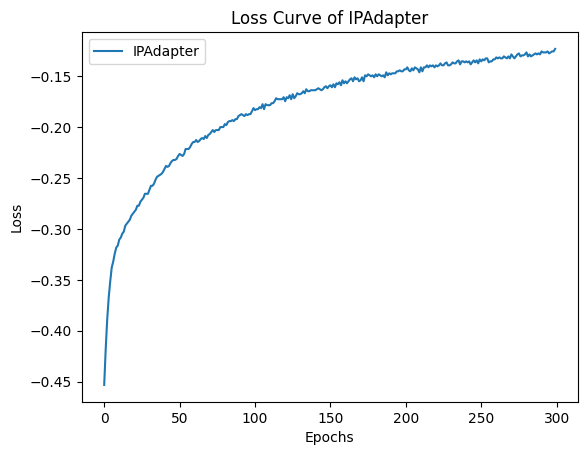

In [9]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IPAdapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IPAdapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## 10 * VAE + 1 * CLIP
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae-ipadapter_yingbu_no-agm-w1-0-w2-10-w3-1_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [10]:
loss_dict_list = [{'loss_sum': -2.8125, 'loss': -24.125, 'vae': -2.359375, 'ipadapter': -0.453125}, {'loss_sum': -2.59375, 'loss': -22.0, 'vae': -2.15625, 'ipadapter': -0.439453125}, {'loss_sum': -2.40625, 'loss': -20.125, 'vae': -1.9765625, 'ipadapter': -0.427734375}, {'loss_sum': -2.28125, 'loss': -19.0, 'vae': -1.859375, 'ipadapter': -0.41796875}, {'loss_sum': -2.1875, 'loss': -18.125, 'vae': -1.78125, 'ipadapter': -0.40625}, {'loss_sum': -2.109375, 'loss': -17.5, 'vae': -1.7109375, 'ipadapter': -0.396484375}, {'loss_sum': -2.046875, 'loss': -17.0, 'vae': -1.6640625, 'ipadapter': -0.38671875}, {'loss_sum': -1.9921875, 'loss': -16.5, 'vae': -1.6171875, 'ipadapter': -0.376953125}, {'loss_sum': -1.9453125, 'loss': -16.125, 'vae': -1.578125, 'ipadapter': -0.3671875}, {'loss_sum': -1.90625, 'loss': -15.875, 'vae': -1.546875, 'ipadapter': -0.36328125}, {'loss_sum': -1.875, 'loss': -15.5, 'vae': -1.515625, 'ipadapter': -0.35546875}, {'loss_sum': -1.84375, 'loss': -15.3125, 'vae': -1.4921875, 'ipadapter': -0.353515625}, {'loss_sum': -1.8203125, 'loss': -15.0625, 'vae': -1.46875, 'ipadapter': -0.349609375}, {'loss_sum': -1.7890625, 'loss': -14.8125, 'vae': -1.4453125, 'ipadapter': -0.345703125}, {'loss_sum': -1.7734375, 'loss': -14.625, 'vae': -1.4296875, 'ipadapter': -0.341796875}, {'loss_sum': -1.75, 'loss': -14.4375, 'vae': -1.4140625, 'ipadapter': -0.33984375}, {'loss_sum': -1.734375, 'loss': -14.3125, 'vae': -1.3984375, 'ipadapter': -0.337890625}, {'loss_sum': -1.71875, 'loss': -14.125, 'vae': -1.3828125, 'ipadapter': -0.333984375}, {'loss_sum': -1.6953125, 'loss': -14.0, 'vae': -1.3671875, 'ipadapter': -0.330078125}, {'loss_sum': -1.6796875, 'loss': -13.8125, 'vae': -1.3515625, 'ipadapter': -0.326171875}, {'loss_sum': -1.671875, 'loss': -13.75, 'vae': -1.34375, 'ipadapter': -0.32421875}, {'loss_sum': -1.65625, 'loss': -13.6875, 'vae': -1.3359375, 'ipadapter': -0.32421875}, {'loss_sum': -1.6484375, 'loss': -13.5625, 'vae': -1.328125, 'ipadapter': -0.322265625}, {'loss_sum': -1.6328125, 'loss': -13.4375, 'vae': -1.3125, 'ipadapter': -0.3203125}, {'loss_sum': -1.625, 'loss': -13.375, 'vae': -1.3046875, 'ipadapter': -0.3203125}, {'loss_sum': -1.625, 'loss': -13.375, 'vae': -1.3046875, 'ipadapter': -0.318359375}, {'loss_sum': -1.609375, 'loss': -13.3125, 'vae': -1.296875, 'ipadapter': -0.31640625}, {'loss_sum': -1.6015625, 'loss': -13.1875, 'vae': -1.2890625, 'ipadapter': -0.314453125}, {'loss_sum': -1.59375, 'loss': -13.125, 'vae': -1.28125, 'ipadapter': -0.3125}, {'loss_sum': -1.59375, 'loss': -13.125, 'vae': -1.28125, 'ipadapter': -0.3125}, {'loss_sum': -1.5859375, 'loss': -13.0625, 'vae': -1.2734375, 'ipadapter': -0.3125}, {'loss_sum': -1.578125, 'loss': -12.9375, 'vae': -1.265625, 'ipadapter': -0.3125}, {'loss_sum': -1.578125, 'loss': -12.9375, 'vae': -1.265625, 'ipadapter': -0.310546875}, {'loss_sum': -1.5625, 'loss': -12.875, 'vae': -1.2578125, 'ipadapter': -0.30859375}, {'loss_sum': -1.5703125, 'loss': -12.875, 'vae': -1.2578125, 'ipadapter': -0.310546875}, {'loss_sum': -1.5625, 'loss': -12.8125, 'vae': -1.25, 'ipadapter': -0.30859375}, {'loss_sum': -1.5625, 'loss': -12.8125, 'vae': -1.25, 'ipadapter': -0.30859375}, {'loss_sum': -1.546875, 'loss': -12.75, 'vae': -1.2421875, 'ipadapter': -0.306640625}, {'loss_sum': -1.546875, 'loss': -12.75, 'vae': -1.2421875, 'ipadapter': -0.306640625}, {'loss_sum': -1.546875, 'loss': -12.75, 'vae': -1.2421875, 'ipadapter': -0.3046875}, {'loss_sum': -1.5390625, 'loss': -12.6875, 'vae': -1.234375, 'ipadapter': -0.302734375}, {'loss_sum': -1.5390625, 'loss': -12.6875, 'vae': -1.234375, 'ipadapter': -0.302734375}, {'loss_sum': -1.5390625, 'loss': -12.6875, 'vae': -1.234375, 'ipadapter': -0.3046875}, {'loss_sum': -1.53125, 'loss': -12.5625, 'vae': -1.2265625, 'ipadapter': -0.302734375}, {'loss_sum': -1.53125, 'loss': -12.5625, 'vae': -1.2265625, 'ipadapter': -0.302734375}, {'loss_sum': -1.53125, 'loss': -12.5625, 'vae': -1.2265625, 'ipadapter': -0.302734375}, {'loss_sum': -1.5234375, 'loss': -12.5, 'vae': -1.21875, 'ipadapter': -0.302734375}, {'loss_sum': -1.5234375, 'loss': -12.5, 'vae': -1.21875, 'ipadapter': -0.302734375}, {'loss_sum': -1.515625, 'loss': -12.5, 'vae': -1.21875, 'ipadapter': -0.30078125}, {'loss_sum': -1.515625, 'loss': -12.4375, 'vae': -1.2109375, 'ipadapter': -0.302734375}, {'loss_sum': -1.515625, 'loss': -12.4375, 'vae': -1.2109375, 'ipadapter': -0.30078125}, {'loss_sum': -1.515625, 'loss': -12.4375, 'vae': -1.2109375, 'ipadapter': -0.30078125}, {'loss_sum': -1.515625, 'loss': -12.4375, 'vae': -1.2109375, 'ipadapter': -0.30078125}, {'loss_sum': -1.5, 'loss': -12.3125, 'vae': -1.203125, 'ipadapter': -0.298828125}, {'loss_sum': -1.5, 'loss': -12.3125, 'vae': -1.203125, 'ipadapter': -0.298828125}, {'loss_sum': -1.5, 'loss': -12.3125, 'vae': -1.203125, 'ipadapter': -0.296875}, {'loss_sum': -1.5, 'loss': -12.3125, 'vae': -1.203125, 'ipadapter': -0.296875}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.296875}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.298828125}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.298828125}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.298828125}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.296875}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.29296875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.29296875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.29296875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.291015625}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.29296875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.291015625}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.291015625}, {'loss_sum': -1.46875, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.29296875}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.291015625}, {'loss_sum': -1.46875, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.29296875}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.291015625}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.291015625}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.2890625}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.2890625}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.287109375}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.287109375}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.287109375}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.287109375}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.4453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.283203125}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.4453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.283203125}, {'loss_sum': -1.4453125, 'loss': -11.875, 'vae': -1.1640625, 'ipadapter': -0.28125}, {'loss_sum': -1.4453125, 'loss': -11.875, 'vae': -1.1640625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.283203125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.283203125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.283203125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.27734375}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.27734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.27734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.27734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.275390625}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.275390625}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.275390625}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.275390625}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.4140625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.271484375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.271484375}, {'loss_sum': -1.4140625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.271484375}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.265625}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.265625}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25390625}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25390625}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2490234375}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2490234375}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.24609375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.24609375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.24609375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.240234375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2412109375}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2421875}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2431640625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2431640625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2431640625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2412109375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}]


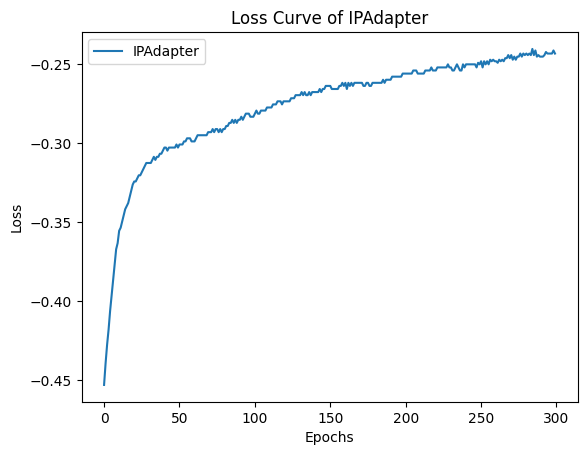

In [11]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IPAdapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IPAdapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## AGM(VAE+IP-Adapter)
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae-ipadapter_yingbu_agm_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [12]:
loss_dict_list = [{'loss_sum': -2.8125, 'loss': -1.3217787742614746, 'vae': -2.359375, 'ipadapter': -0.453125}, {'loss_sum': -2.609375, 'loss': -1.0572600364685059, 'vae': -2.1875, 'ipadapter': -0.423828125}, {'loss_sum': -2.4375, 'loss': -1.1028938293457031, 'vae': -2.046875, 'ipadapter': -0.3984375}, {'loss_sum': -2.296875, 'loss': -1.018142580986023, 'vae': -1.921875, 'ipadapter': -0.376953125}, {'loss_sum': -2.203125, 'loss': -1.0157577991485596, 'vae': -1.8359375, 'ipadapter': -0.36328125}, {'loss_sum': -2.109375, 'loss': -0.9424364566802979, 'vae': -1.765625, 'ipadapter': -0.349609375}, {'loss_sum': -2.046875, 'loss': -0.9201123714447021, 'vae': -1.7109375, 'ipadapter': -0.33984375}, {'loss_sum': -2.0, 'loss': -0.8597550392150879, 'vae': -1.671875, 'ipadapter': -0.333984375}, {'loss_sum': -1.96875, 'loss': -0.8918200731277466, 'vae': -1.640625, 'ipadapter': -0.328125}, {'loss_sum': -1.9375, 'loss': -0.8169972896575928, 'vae': -1.609375, 'ipadapter': -0.32421875}, {'loss_sum': -1.8984375, 'loss': -0.8546525835990906, 'vae': -1.578125, 'ipadapter': -0.3203125}, {'loss_sum': -1.875, 'loss': -0.7828946709632874, 'vae': -1.5546875, 'ipadapter': -0.31640625}, {'loss_sum': -1.84375, 'loss': -0.8208835124969482, 'vae': -1.53125, 'ipadapter': -0.310546875}, {'loss_sum': -1.8125, 'loss': -0.7536799907684326, 'vae': -1.5078125, 'ipadapter': -0.306640625}, {'loss_sum': -1.796875, 'loss': -0.7616189122200012, 'vae': -1.4921875, 'ipadapter': -0.3046875}, {'loss_sum': -1.7734375, 'loss': -0.7503950595855713, 'vae': -1.46875, 'ipadapter': -0.302734375}, {'loss_sum': -1.75, 'loss': -0.7703445553779602, 'vae': -1.453125, 'ipadapter': -0.298828125}, {'loss_sum': -1.734375, 'loss': -0.7144676446914673, 'vae': -1.4375, 'ipadapter': -0.296875}, {'loss_sum': -1.7265625, 'loss': -0.775892972946167, 'vae': -1.4296875, 'ipadapter': -0.296875}, {'loss_sum': -1.7109375, 'loss': -0.7177472114562988, 'vae': -1.421875, 'ipadapter': -0.291015625}, {'loss_sum': -1.6953125, 'loss': -0.7594664692878723, 'vae': -1.40625, 'ipadapter': -0.291015625}, {'loss_sum': -1.6875, 'loss': -0.7205843925476074, 'vae': -1.3984375, 'ipadapter': -0.2890625}, {'loss_sum': -1.6796875, 'loss': -0.7327212691307068, 'vae': -1.390625, 'ipadapter': -0.287109375}, {'loss_sum': -1.6640625, 'loss': -0.6933284997940063, 'vae': -1.3828125, 'ipadapter': -0.283203125}, {'loss_sum': -1.65625, 'loss': -0.706356406211853, 'vae': -1.375, 'ipadapter': -0.283203125}, {'loss_sum': -1.6484375, 'loss': -0.6845417618751526, 'vae': -1.3671875, 'ipadapter': -0.28125}, {'loss_sum': -1.640625, 'loss': -0.6927467584609985, 'vae': -1.359375, 'ipadapter': -0.27734375}, {'loss_sum': -1.625, 'loss': -0.6731368899345398, 'vae': -1.3515625, 'ipadapter': -0.27734375}, {'loss_sum': -1.6171875, 'loss': -0.6680374145507812, 'vae': -1.34375, 'ipadapter': -0.275390625}, {'loss_sum': -1.6171875, 'loss': -0.6658824682235718, 'vae': -1.34375, 'ipadapter': -0.2734375}, {'loss_sum': -1.609375, 'loss': -0.6911975741386414, 'vae': -1.3359375, 'ipadapter': -0.271484375}, {'loss_sum': -1.609375, 'loss': -0.6596157550811768, 'vae': -1.3359375, 'ipadapter': -0.26953125}, {'loss_sum': -1.59375, 'loss': -0.6861600875854492, 'vae': -1.328125, 'ipadapter': -0.26953125}, {'loss_sum': -1.5859375, 'loss': -0.6494693756103516, 'vae': -1.3203125, 'ipadapter': -0.265625}, {'loss_sum': -1.5859375, 'loss': -0.6627197265625, 'vae': -1.3203125, 'ipadapter': -0.265625}, {'loss_sum': -1.578125, 'loss': -0.6905020475387573, 'vae': -1.3125, 'ipadapter': -0.265625}, {'loss_sum': -1.578125, 'loss': -0.6394864320755005, 'vae': -1.3125, 'ipadapter': -0.26171875}, {'loss_sum': -1.5703125, 'loss': -0.6708648800849915, 'vae': -1.3046875, 'ipadapter': -0.263671875}, {'loss_sum': -1.5625, 'loss': -0.6496100425720215, 'vae': -1.3046875, 'ipadapter': -0.259765625}, {'loss_sum': -1.5625, 'loss': -0.665492057800293, 'vae': -1.3046875, 'ipadapter': -0.2578125}, {'loss_sum': -1.5546875, 'loss': -0.6919823884963989, 'vae': -1.296875, 'ipadapter': -0.255859375}, {'loss_sum': -1.546875, 'loss': -0.6547994017601013, 'vae': -1.296875, 'ipadapter': -0.25390625}, {'loss_sum': -1.546875, 'loss': -0.607577383518219, 'vae': -1.296875, 'ipadapter': -0.251953125}, {'loss_sum': -1.5390625, 'loss': -0.6345832943916321, 'vae': -1.2890625, 'ipadapter': -0.251953125}, {'loss_sum': -1.5390625, 'loss': -0.6676111221313477, 'vae': -1.2890625, 'ipadapter': -0.251953125}, {'loss_sum': -1.5390625, 'loss': -0.6051458716392517, 'vae': -1.2890625, 'ipadapter': -0.248046875}, {'loss_sum': -1.53125, 'loss': -0.6229445934295654, 'vae': -1.28125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.53125, 'loss': -0.5988539457321167, 'vae': -1.28125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.53125, 'loss': -0.583925187587738, 'vae': -1.28125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.53125, 'loss': -0.6477271914482117, 'vae': -1.28125, 'ipadapter': -0.24609375}, {'loss_sum': -1.515625, 'loss': -0.5984607934951782, 'vae': -1.2734375, 'ipadapter': -0.2412109375}, {'loss_sum': -1.515625, 'loss': -0.5852071642875671, 'vae': -1.2734375, 'ipadapter': -0.2392578125}, {'loss_sum': -1.515625, 'loss': -0.6269693374633789, 'vae': -1.2734375, 'ipadapter': -0.240234375}, {'loss_sum': -1.5078125, 'loss': -0.5975425243377686, 'vae': -1.2734375, 'ipadapter': -0.236328125}, {'loss_sum': -1.5, 'loss': -0.5979716181755066, 'vae': -1.265625, 'ipadapter': -0.2373046875}, {'loss_sum': -1.5, 'loss': -0.578737735748291, 'vae': -1.265625, 'ipadapter': -0.2353515625}, {'loss_sum': -1.5, 'loss': -0.5997508764266968, 'vae': -1.265625, 'ipadapter': -0.234375}, {'loss_sum': -1.5, 'loss': -0.615925669670105, 'vae': -1.265625, 'ipadapter': -0.2333984375}, {'loss_sum': -1.484375, 'loss': -0.5587618947029114, 'vae': -1.2578125, 'ipadapter': -0.2294921875}, {'loss_sum': -1.4921875, 'loss': -0.5667195320129395, 'vae': -1.2578125, 'ipadapter': -0.2314453125}, {'loss_sum': -1.484375, 'loss': -0.5087116360664368, 'vae': -1.2578125, 'ipadapter': -0.23046875}, {'loss_sum': -1.484375, 'loss': -0.6315276622772217, 'vae': -1.2578125, 'ipadapter': -0.23046875}, {'loss_sum': -1.484375, 'loss': -0.547501802444458, 'vae': -1.2578125, 'ipadapter': -0.2275390625}, {'loss_sum': -1.484375, 'loss': -0.5846230387687683, 'vae': -1.2578125, 'ipadapter': -0.2255859375}, {'loss_sum': -1.484375, 'loss': -0.5593335628509521, 'vae': -1.2578125, 'ipadapter': -0.224609375}, {'loss_sum': -1.4765625, 'loss': -0.555942952632904, 'vae': -1.25, 'ipadapter': -0.224609375}, {'loss_sum': -1.46875, 'loss': -0.5756236910820007, 'vae': -1.25, 'ipadapter': -0.22265625}, {'loss_sum': -1.46875, 'loss': -0.5342550277709961, 'vae': -1.25, 'ipadapter': -0.22265625}, {'loss_sum': -1.46875, 'loss': -0.5584546327590942, 'vae': -1.25, 'ipadapter': -0.22265625}, {'loss_sum': -1.46875, 'loss': -0.4962127208709717, 'vae': -1.25, 'ipadapter': -0.220703125}, {'loss_sum': -1.4609375, 'loss': -0.5368607044219971, 'vae': -1.2421875, 'ipadapter': -0.2216796875}, {'loss_sum': -1.4609375, 'loss': -0.5317544937133789, 'vae': -1.2421875, 'ipadapter': -0.21875}, {'loss_sum': -1.4609375, 'loss': -0.5526188611984253, 'vae': -1.2421875, 'ipadapter': -0.21875}, {'loss_sum': -1.4609375, 'loss': -0.5141423940658569, 'vae': -1.2421875, 'ipadapter': -0.2158203125}, {'loss_sum': -1.4609375, 'loss': -0.5717964172363281, 'vae': -1.2421875, 'ipadapter': -0.216796875}, {'loss_sum': -1.453125, 'loss': -0.5243050456047058, 'vae': -1.2421875, 'ipadapter': -0.212890625}, {'loss_sum': -1.453125, 'loss': -0.5016152858734131, 'vae': -1.2421875, 'ipadapter': -0.212890625}, {'loss_sum': -1.4453125, 'loss': -0.5530298948287964, 'vae': -1.234375, 'ipadapter': -0.2138671875}, {'loss_sum': -1.4453125, 'loss': -0.5050370693206787, 'vae': -1.234375, 'ipadapter': -0.2119140625}, {'loss_sum': -1.4453125, 'loss': -0.5033082962036133, 'vae': -1.234375, 'ipadapter': -0.2109375}, {'loss_sum': -1.4453125, 'loss': -0.5487479567527771, 'vae': -1.234375, 'ipadapter': -0.2119140625}, {'loss_sum': -1.4453125, 'loss': -0.6063350439071655, 'vae': -1.234375, 'ipadapter': -0.2080078125}, {'loss_sum': -1.4375, 'loss': -0.5177114009857178, 'vae': -1.234375, 'ipadapter': -0.205078125}, {'loss_sum': -1.4375, 'loss': -0.5849193334579468, 'vae': -1.234375, 'ipadapter': -0.20703125}, {'loss_sum': -1.4375, 'loss': -0.5265854597091675, 'vae': -1.234375, 'ipadapter': -0.2060546875}, {'loss_sum': -1.4375, 'loss': -0.4827690124511719, 'vae': -1.234375, 'ipadapter': -0.2041015625}, {'loss_sum': -1.4296875, 'loss': -0.5490134954452515, 'vae': -1.2265625, 'ipadapter': -0.205078125}, {'loss_sum': -1.4296875, 'loss': -0.4626440405845642, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.4296875, 'loss': -0.5505151748657227, 'vae': -1.2265625, 'ipadapter': -0.2041015625}, {'loss_sum': -1.4296875, 'loss': -0.47207051515579224, 'vae': -1.2265625, 'ipadapter': -0.2001953125}, {'loss_sum': -1.4296875, 'loss': -0.5481967926025391, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.421875, 'loss': -0.5098944902420044, 'vae': -1.2265625, 'ipadapter': -0.19921875}, {'loss_sum': -1.4296875, 'loss': -0.49713432788848877, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.4296875, 'loss': -0.5130491256713867, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.4296875, 'loss': -0.48875656723976135, 'vae': -1.2265625, 'ipadapter': -0.201171875}, {'loss_sum': -1.4296875, 'loss': -0.5715539455413818, 'vae': -1.2265625, 'ipadapter': -0.2001953125}, {'loss_sum': -1.421875, 'loss': -0.5051389932632446, 'vae': -1.2265625, 'ipadapter': -0.197265625}, {'loss_sum': -1.421875, 'loss': -0.465192973613739, 'vae': -1.2265625, 'ipadapter': -0.197265625}, {'loss_sum': -1.421875, 'loss': -0.5331618189811707, 'vae': -1.2265625, 'ipadapter': -0.19921875}, {'loss_sum': -1.4140625, 'loss': -0.4643414616584778, 'vae': -1.21875, 'ipadapter': -0.197265625}, {'loss_sum': -1.421875, 'loss': -0.544404149055481, 'vae': -1.21875, 'ipadapter': -0.19921875}, {'loss_sum': -1.4140625, 'loss': -0.5686902403831482, 'vae': -1.21875, 'ipadapter': -0.197265625}, {'loss_sum': -1.4140625, 'loss': -0.45783472061157227, 'vae': -1.21875, 'ipadapter': -0.1943359375}, {'loss_sum': -1.4140625, 'loss': -0.5439262986183167, 'vae': -1.21875, 'ipadapter': -0.1962890625}, {'loss_sum': -1.4140625, 'loss': -0.49593114852905273, 'vae': -1.21875, 'ipadapter': -0.193359375}, {'loss_sum': -1.40625, 'loss': -0.44602370262145996, 'vae': -1.21875, 'ipadapter': -0.19140625}, {'loss_sum': -1.4140625, 'loss': -0.560116708278656, 'vae': -1.21875, 'ipadapter': -0.1953125}, {'loss_sum': -1.40625, 'loss': -0.45865944027900696, 'vae': -1.21875, 'ipadapter': -0.1904296875}, {'loss_sum': -1.4140625, 'loss': -0.4625466763973236, 'vae': -1.21875, 'ipadapter': -0.1923828125}, {'loss_sum': -1.4140625, 'loss': -0.4754870533943176, 'vae': -1.21875, 'ipadapter': -0.1923828125}, {'loss_sum': -1.40625, 'loss': -0.48872649669647217, 'vae': -1.2109375, 'ipadapter': -0.19140625}, {'loss_sum': -1.3984375, 'loss': -0.46806764602661133, 'vae': -1.2109375, 'ipadapter': -0.1884765625}, {'loss_sum': -1.3984375, 'loss': -0.4986814558506012, 'vae': -1.2109375, 'ipadapter': -0.1904296875}, {'loss_sum': -1.3984375, 'loss': -0.4299588203430176, 'vae': -1.2109375, 'ipadapter': -0.1884765625}, {'loss_sum': -1.3984375, 'loss': -0.4895952045917511, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.3984375, 'loss': -0.450664222240448, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.40625, 'loss': -0.5012716054916382, 'vae': -1.2109375, 'ipadapter': -0.1923828125}, {'loss_sum': -1.40625, 'loss': -0.47248125076293945, 'vae': -1.2109375, 'ipadapter': -0.19140625}, {'loss_sum': -1.3984375, 'loss': -0.4856449067592621, 'vae': -1.2109375, 'ipadapter': -0.1904296875}, {'loss_sum': -1.3984375, 'loss': -0.5483509302139282, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.3984375, 'loss': -0.42720842361450195, 'vae': -1.2109375, 'ipadapter': -0.1865234375}, {'loss_sum': -1.3984375, 'loss': -0.5142333507537842, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.3984375, 'loss': -0.46544021368026733, 'vae': -1.2109375, 'ipadapter': -0.185546875}, {'loss_sum': -1.3984375, 'loss': -0.46141916513442993, 'vae': -1.2109375, 'ipadapter': -0.185546875}, {'loss_sum': -1.3984375, 'loss': -0.46473023295402527, 'vae': -1.2109375, 'ipadapter': -0.1845703125}, {'loss_sum': -1.390625, 'loss': -0.4613924026489258, 'vae': -1.2109375, 'ipadapter': -0.18359375}, {'loss_sum': -1.390625, 'loss': -0.46355023980140686, 'vae': -1.2109375, 'ipadapter': -0.1826171875}, {'loss_sum': -1.390625, 'loss': -0.44038066267967224, 'vae': -1.2109375, 'ipadapter': -0.181640625}, {'loss_sum': -1.3828125, 'loss': -0.4722369313240051, 'vae': -1.203125, 'ipadapter': -0.1826171875}, {'loss_sum': -1.390625, 'loss': -0.42393046617507935, 'vae': -1.2109375, 'ipadapter': -0.1826171875}, {'loss_sum': -1.3828125, 'loss': -0.43914785981178284, 'vae': -1.203125, 'ipadapter': -0.1826171875}, {'loss_sum': -1.3828125, 'loss': -0.4759468734264374, 'vae': -1.203125, 'ipadapter': -0.181640625}, {'loss_sum': -1.3828125, 'loss': -0.44733726978302, 'vae': -1.203125, 'ipadapter': -0.1796875}, {'loss_sum': -1.3828125, 'loss': -0.4265759587287903, 'vae': -1.203125, 'ipadapter': -0.1787109375}, {'loss_sum': -1.3828125, 'loss': -0.44375717639923096, 'vae': -1.203125, 'ipadapter': -0.1796875}, {'loss_sum': -1.3828125, 'loss': -0.4683346152305603, 'vae': -1.203125, 'ipadapter': -0.1787109375}, {'loss_sum': -1.3828125, 'loss': -0.4237198233604431, 'vae': -1.203125, 'ipadapter': -0.1767578125}, {'loss_sum': -1.3828125, 'loss': -0.47620290517807007, 'vae': -1.203125, 'ipadapter': -0.177734375}, {'loss_sum': -1.3828125, 'loss': -0.4490460753440857, 'vae': -1.203125, 'ipadapter': -0.1767578125}, {'loss_sum': -1.3828125, 'loss': -0.45421597361564636, 'vae': -1.203125, 'ipadapter': -0.177734375}, {'loss_sum': -1.375, 'loss': -0.43321770429611206, 'vae': -1.203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.375, 'loss': -0.43321770429611206, 'vae': -1.203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.375, 'loss': -0.4521781802177429, 'vae': -1.203125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.4226346015930176, 'vae': -1.203125, 'ipadapter': -0.1728515625}, {'loss_sum': -1.375, 'loss': -0.4353674352169037, 'vae': -1.203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.375, 'loss': -0.39620834589004517, 'vae': -1.203125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.4411097764968872, 'vae': -1.203125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.42749810218811035, 'vae': -1.203125, 'ipadapter': -0.1728515625}, {'loss_sum': -1.375, 'loss': -0.413213849067688, 'vae': -1.203125, 'ipadapter': -0.169921875}, {'loss_sum': -1.375, 'loss': -0.38243842124938965, 'vae': -1.203125, 'ipadapter': -0.171875}, {'loss_sum': -1.3671875, 'loss': -0.4632995128631592, 'vae': -1.1953125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.45409947633743286, 'vae': -1.203125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.375, 'loss': -0.4057199954986572, 'vae': -1.203125, 'ipadapter': -0.169921875}, {'loss_sum': -1.3671875, 'loss': -0.45266467332839966, 'vae': -1.1953125, 'ipadapter': -0.171875}, {'loss_sum': -1.375, 'loss': -0.4543617069721222, 'vae': -1.203125, 'ipadapter': -0.169921875}, {'loss_sum': -1.3671875, 'loss': -0.4461195468902588, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.3671875, 'loss': -0.4504951536655426, 'vae': -1.1953125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.375, 'loss': -0.4393238425254822, 'vae': -1.203125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.3671875, 'loss': -0.437292218208313, 'vae': -1.1953125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.3671875, 'loss': -0.4571712613105774, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.359375, 'loss': -0.4009758234024048, 'vae': -1.1953125, 'ipadapter': -0.16796875}, {'loss_sum': -1.3671875, 'loss': -0.4643170237541199, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.359375, 'loss': -0.3915415108203888, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.359375, 'loss': -0.44878116250038147, 'vae': -1.1953125, 'ipadapter': -0.166015625}, {'loss_sum': -1.359375, 'loss': -0.43386244773864746, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.359375, 'loss': -0.45266157388687134, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.359375, 'loss': -0.40622955560684204, 'vae': -1.1953125, 'ipadapter': -0.166015625}, {'loss_sum': -1.359375, 'loss': -0.3923042416572571, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.3671875, 'loss': -0.4524135887622833, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.359375, 'loss': -0.3980116546154022, 'vae': -1.1953125, 'ipadapter': -0.1650390625}, {'loss_sum': -1.359375, 'loss': -0.4370037913322449, 'vae': -1.1953125, 'ipadapter': -0.166015625}, {'loss_sum': -1.359375, 'loss': -0.43257176876068115, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.359375, 'loss': -0.43257176876068115, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.3671875, 'loss': -0.3716816306114197, 'vae': -1.203125, 'ipadapter': -0.162109375}, {'loss_sum': -1.359375, 'loss': -0.45247602462768555, 'vae': -1.1953125, 'ipadapter': -0.1650390625}, {'loss_sum': -1.359375, 'loss': -0.3887764811515808, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.359375, 'loss': -0.46840763092041016, 'vae': -1.1953125, 'ipadapter': -0.1630859375}, {'loss_sum': -1.359375, 'loss': -0.41946882009506226, 'vae': -1.1953125, 'ipadapter': -0.16015625}, {'loss_sum': -1.359375, 'loss': -0.4119584858417511, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.359375, 'loss': -0.4472495913505554, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.3515625, 'loss': -0.344230592250824, 'vae': -1.1953125, 'ipadapter': -0.1591796875}, {'loss_sum': -1.359375, 'loss': -0.42397016286849976, 'vae': -1.1953125, 'ipadapter': -0.1640625}, {'loss_sum': -1.359375, 'loss': -0.4442589282989502, 'vae': -1.1953125, 'ipadapter': -0.16015625}, {'loss_sum': -1.3515625, 'loss': -0.35660988092422485, 'vae': -1.1953125, 'ipadapter': -0.1591796875}, {'loss_sum': -1.359375, 'loss': -0.44048774242401123, 'vae': -1.1953125, 'ipadapter': -0.1630859375}, {'loss_sum': -1.359375, 'loss': -0.3962518572807312, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.359375, 'loss': -0.3924022912979126, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.359375, 'loss': -0.4247996509075165, 'vae': -1.1953125, 'ipadapter': -0.16015625}, {'loss_sum': -1.3515625, 'loss': -0.39532577991485596, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.4292185306549072, 'vae': -1.1875, 'ipadapter': -0.1591796875}, {'loss_sum': -1.3515625, 'loss': -0.39532577991485596, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.3515625, 'loss': -0.4193830192089081, 'vae': -1.1953125, 'ipadapter': -0.1572265625}, {'loss_sum': -1.34375, 'loss': -0.39117199182510376, 'vae': -1.1875, 'ipadapter': -0.1572265625}, {'loss_sum': -1.34375, 'loss': -0.4046756625175476, 'vae': -1.1875, 'ipadapter': -0.158203125}, {'loss_sum': -1.3515625, 'loss': -0.4594101011753082, 'vae': -1.1953125, 'ipadapter': -0.1591796875}, {'loss_sum': -1.3515625, 'loss': -0.3820646405220032, 'vae': -1.1953125, 'ipadapter': -0.1552734375}, {'loss_sum': -1.359375, 'loss': -0.45431020855903625, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3515625, 'loss': -0.3846995532512665, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.39748841524124146, 'vae': -1.1875, 'ipadapter': -0.1591796875}, {'loss_sum': -1.34375, 'loss': -0.4032214879989624, 'vae': -1.1875, 'ipadapter': -0.16015625}, {'loss_sum': -1.3515625, 'loss': -0.3852676451206207, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.39967286586761475, 'vae': -1.1875, 'ipadapter': -0.1572265625}, {'loss_sum': -1.34375, 'loss': -0.3938411474227905, 'vae': -1.1875, 'ipadapter': -0.15625}, {'loss_sum': -1.34375, 'loss': -0.3820631206035614, 'vae': -1.1875, 'ipadapter': -0.1552734375}, {'loss_sum': -1.34375, 'loss': -0.3770877718925476, 'vae': -1.1875, 'ipadapter': -0.15625}, {'loss_sum': -1.3515625, 'loss': -0.3641347885131836, 'vae': -1.1953125, 'ipadapter': -0.1552734375}, {'loss_sum': -1.34375, 'loss': -0.4313795864582062, 'vae': -1.1875, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.41646838188171387, 'vae': -1.1875, 'ipadapter': -0.154296875}, {'loss_sum': -1.34375, 'loss': -0.36898285150527954, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.34375, 'loss': -0.37444940209388733, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.34375, 'loss': -0.40170156955718994, 'vae': -1.1875, 'ipadapter': -0.154296875}, {'loss_sum': -1.34375, 'loss': -0.37686604261398315, 'vae': -1.1875, 'ipadapter': -0.154296875}, {'loss_sum': -1.34375, 'loss': -0.40021613240242004, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.34375, 'loss': -0.3399208188056946, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.34375, 'loss': -0.45443543791770935, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.3359375, 'loss': -0.33764684200286865, 'vae': -1.1875, 'ipadapter': -0.150390625}, {'loss_sum': -1.3359375, 'loss': -0.411531925201416, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.3789353668689728, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.37735825777053833, 'vae': -1.1875, 'ipadapter': -0.150390625}, {'loss_sum': -1.34375, 'loss': -0.42236194014549255, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.3359375, 'loss': -0.38448476791381836, 'vae': -1.1875, 'ipadapter': -0.1484375}, {'loss_sum': -1.3359375, 'loss': -0.34152525663375854, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.34375, 'loss': -0.43320488929748535, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.3359375, 'loss': -0.3526016175746918, 'vae': -1.1875, 'ipadapter': -0.150390625}, {'loss_sum': -1.3359375, 'loss': -0.3885512351989746, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.411531925201416, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.3681707978248596, 'vae': -1.1875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.3359375, 'loss': -0.34152525663375854, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.34375, 'loss': -0.4355579614639282, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.3359375, 'loss': -0.3047633171081543, 'vae': -1.1875, 'ipadapter': -0.1484375}, {'loss_sum': -1.34375, 'loss': -0.4330432713031769, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.3359375, 'loss': -0.3185359835624695, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.38084086775779724, 'vae': -1.1875, 'ipadapter': -0.1484375}, {'loss_sum': -1.3359375, 'loss': -0.3408583998680115, 'vae': -1.1875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.3359375, 'loss': -0.4025043845176697, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.32933664321899414, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.4932549297809601, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.3419486880302429, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.3359375, 'loss': -0.37132227420806885, 'vae': -1.1875, 'ipadapter': -0.1494140625}, {'loss_sum': -1.3359375, 'loss': -0.3391442596912384, 'vae': -1.1875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.3359375, 'loss': -0.36959630250930786, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.38959020376205444, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.328125, 'loss': -0.3375392258167267, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.3359375, 'loss': -0.4373660087585449, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.328125, 'loss': -0.38076043128967285, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.35191065073013306, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.37088531255722046, 'vae': -1.1796875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.34458744525909424, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.3359375, 'loss': -0.3893046975135803, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.35614287853240967, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.3234248757362366, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.37903040647506714, 'vae': -1.1796875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.3359375, 'loss': -0.3497099280357361, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.3595173954963684, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.38597241044044495, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3467208743095398, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.3203125, 'loss': -0.35035139322280884, 'vae': -1.1796875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.4115852415561676, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.312343031167984, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.3203125, 'loss': -0.36888444423675537, 'vae': -1.1796875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.3359375, 'loss': -0.4265281856060028, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.3386293351650238, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.386722207069397, 'vae': -1.1875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.312100887298584, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.4046920835971832, 'vae': -1.1875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.3103858232498169, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3359375, 'loss': -0.38405340909957886, 'vae': -1.1953125, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3441086411476135, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.3467208743095398, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.3696199059486389, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.42641592025756836, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.3203125, 'loss': -0.36186325550079346, 'vae': -1.1796875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.33801424503326416, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.39235976338386536, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.3543083965778351, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.39235976338386536, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.3467208743095398, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.3696105480194092, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.33942121267318726, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.4359877109527588, 'vae': -1.1875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.336028128862381, 'vae': -1.1875, 'ipadapter': -0.1396484375}, {'loss_sum': -1.328125, 'loss': -0.38433313369750977, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3191661536693573, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3203125, 'loss': -0.3707229495048523, 'vae': -1.1796875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.4116823673248291, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.316736102104187, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.3203125, 'loss': -0.42570972442626953, 'vae': -1.1796875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3933931887149811, 'vae': -1.1875, 'ipadapter': -0.1396484375}, {'loss_sum': -1.328125, 'loss': -0.29765865206718445, 'vae': -1.1875, 'ipadapter': -0.138671875}, {'loss_sum': -1.328125, 'loss': -0.4009018540382385, 'vae': -1.1796875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.3441086411476135, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.3801546096801758, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3203125, 'loss': -0.35218489170074463, 'vae': -1.1796875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.3044087290763855, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3203125, 'loss': -0.4266808331012726, 'vae': -1.1796875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.3682662844657898, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.328125, 'loss': -0.34374210238456726, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.328125, 'loss': -0.31531789898872375, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.328125, 'loss': -0.35888612270355225, 'vae': -1.1875, 'ipadapter': -0.138671875}, {'loss_sum': -1.328125, 'loss': -0.3605197072029114, 'vae': -1.1875, 'ipadapter': -0.138671875}]


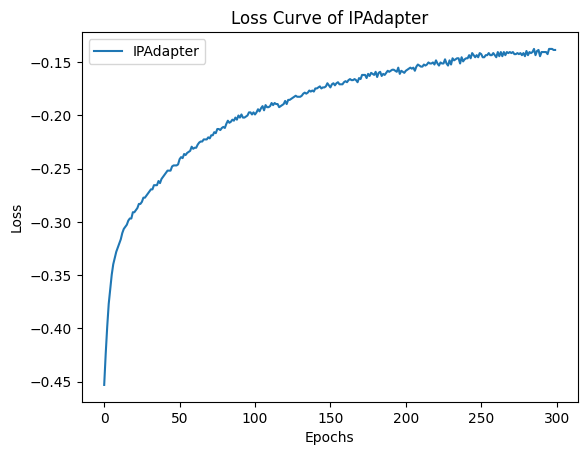

In [13]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IPAdapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IPAdapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()